In [1]:
import os 
os.chdir("/scale/user/mtannaou/alternance")
from src.visualisation.utils_colormap import CMAP
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pyresample
import pyproj

cmap_ir = CMAP.cira_ir()
cmap_sar = CMAP.cmap_sar()

def plot_sar(tensor, fig=None, ax=None, cmap=cmap_sar, title=None,
             x_lim=300, x=None, y=None):

    if ax is None:
        ax = plt.gca()

    if x is None:
        y_sar = np.linspace(-x_lim, x_lim, tensor.shape[0])
        x_sar = np.linspace(-x_lim, x_lim, tensor.shape[1])
        x_sar, y_sar = np.meshgrid(x_sar, y_sar)
    else:
        x_sar, y_sar = x, y   # déjà 2D, pas de meshgrid

    im = ax.pcolormesh(
        x_sar,
        y_sar,
        tensor,
        cmap=cmap,
        vmin=0,
        vmax=160/1.94384449,
        shading="auto"
    )

    if x is None:
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-x_lim, x_lim)

    if title is not None:
        ax.set_title(title)

    if fig is not None:
        fig.colorbar(im, ax=ax, orientation="horizontal")

    ax.set_aspect("equal")


def plot_ir(tensor, fig=None, x=None, y=None, ax=None, x_lim=300,
            cmap=cmap_ir, vmin=-100, vmax=50):

    if ax is None:
        ax = plt.gca()

    tensor = np.squeeze(tensor)
    ny, nx = tensor.shape  # ny = rows, nx = cols

    if x is None:
        x = np.linspace(-x_lim, x_lim, nx)

    if y is None:
        y = np.linspace(-x_lim, x_lim, ny)

    im = ax.pcolormesh(
        x, y, tensor,
        cmap=cmap,
        shading="nearest",
        vmin=vmin,
        vmax=vmax
    )

    if x is None or y is None:
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-x_lim, x_lim)
    else:
        ax.set_xlim(np.min(x), np.max(x))
        ax.set_ylim(np.min(y), np.max(y))
    ax.set_aspect("equal")

    if fig is not None:
        fig.colorbar(im, ax=ax, orientation="horizontal")


 
def build_storm_centered_dataset(
    ds,
    half_size=500,
    dxy=2.0,
    kind="nearest"
):
    """
    Construit un dataset centré cyclone sur grille régulière [-500, 500] km.

    Returns
    -------
    xr.Dataset
    """

    ir = ds["brightness_temperature"].values
    ir_lon = ((ds["longitude"].values+180)%360)-180
    ir_lat = ds["latitude"].values
    center_lat = ds["storm_latitude"].values[0]
    center_lon = ((ds["storm_longitude"][0].values + 180)%360)-180

    nx = ny = int(2 * half_size / dxy) + 1

    x = np.linspace(-half_size, half_size, nx)
    y = np.linspace(half_size, -half_size, ny)  # nord en haut

    proj = pyproj.Proj(              #place le cyclone au centre (0,0), et je mesure tout en km autou
        proj="aeqd",
        lat_0=center_lat,
        lon_0=center_lon,
        ellps="WGS84",
        units="km"
    )


    longitude, latitude = pyresample.utils.check_and_wrap(ir_lon, ir_lat)
    lon2d, lat2d = np.meshgrid(longitude, latitude)

    swath_ir = pyresample.SwathDefinition(
        lon2d,
        lat2d
    )

    area_def = pyresample.geometry.AreaDefinition(
        "storm",
        "storm centered grid",
        "storm",
        proj.srs,
        nx,
        ny,
        (x[0] - dxy/2, y[-1] - dxy/2, x[-1] + dxy/2, y[0] + dxy/2)
    )

    if kind == "nearest":
        ir_grid = pyresample.kd_tree.resample_nearest(
            swath_ir,
            ir,
            area_def,
            radius_of_influence=100000,
            fill_value=np.nan
        )
    else:
        ir_grid = pyresample.kd_tree.resample_gauss(
            swath_ir,
            ir,
            area_def,
            radius_of_influence=100000,
            sigmas=25000
        )

   

    ds["ir_aeqd"] = xr.DataArray(
            ir_grid,
            dims=("y", "x"),
            coords={
                "x": x,
                "y": y,
            },
            attrs={
                "units": ds["brightness_temperature"].attrs.get("units", ""),
                "description": "Brightness temperature projected onto storm-centered AEQD grid",
            },
        )

    ds["center_lat"] = center_lat
    ds["center_lon"] = center_lon

    return ds

In [7]:
import os
os.chdir("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR")
os.getcwd()

'/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR'

## regrillage de tous les infra rouges de IRAR

In [ ]:
irar_path = "/scale/project/ifremer-isi-jumeaunumerique/IRAR_BestTrack_corrected"
import os; import xarray as xr;from tqdm import tqdm

totale = 0
valide = 0
for year in tqdm(os.listdir(irar_path), desc="Regrided All IRAR samples :", total=len(os.listdir(irar_path))):
    year_path = os.path.join(irar_path,year)
    for cyc_id in os.listdir(year_path):
        cyc_id_path = os.path.join(year_path,cyc_id)
        for path in os.listdir(cyc_id_path):
            if "aeqd" in path :
                continue
            totale += 1
            path_nc = os.path.join(cyc_id_path,path)

            try : 
                ds = xr.open_dataset(path_nc)
                ds = ds.where(ds != -999.0)
                ds = build_storm_centered_dataset(ds)

                tmp_path = path_nc + ".tmp"

                ds.to_netcdf(tmp_path)

                os.replace(tmp_path, path_nc)
                valide += 1
            except  Exception as e:
                print("error",e)
                continue

Regrided All IRAR samples ::   0%|          | 0/9 [00:00<?, ?it/s]

error "No variable named 'brightness_temperature'. Variables on the dataset include []"
error "No variable named 'brightness_temperature'. Variables on the dataset include []"
error "No variable named 'brightness_temperature'. Variables on the dataset include []"
error "No variable named 'brightness_temperature'. Variables on the dataset include []"
error "No variable named 'brightness_temperature'. Variables on the dataset include []"
error "No variable named 'brightness_temperature'. Variables on the dataset include []"


Regrided All IRAR samples ::  33%|███▎      | 3/9 [16:36:57<27:26:01, 16460.19s/it]

error "No variable named 'brightness_temperature'. Variables on the dataset include []"


Regrided All IRAR samples ::  44%|████▍     | 4/9 [21:26:18<23:21:19, 16815.87s/it]

error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km 

Regrided All IRAR samples ::  56%|█████▌    | 5/9 [27:40:33<20:56:38, 18849.60s/it]

error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error "No variable named 'brightness_temperature'. Variables on the dataset include []"
error "No variable named 'brightness_temperature'. Variables on the dataset include []"
error "No variable named 'brightness_temperature'. Variables on the dataset include []"
error "No variable named 'brightness_temperature'. Variables on the dataset include []"
error "No variable named 'brightness

Regrided All IRAR samples ::  67%|██████▋   | 6/9 [36:17:56<19:09:46, 22995.36s/it]

error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km +type=crs: (Internal Proj Error: proj_create: invalid value for lat_0)
error Invalid projection: +proj=aeqd +lat_0=nan +lon_0=nan +ellps=WGS84 +units=km 

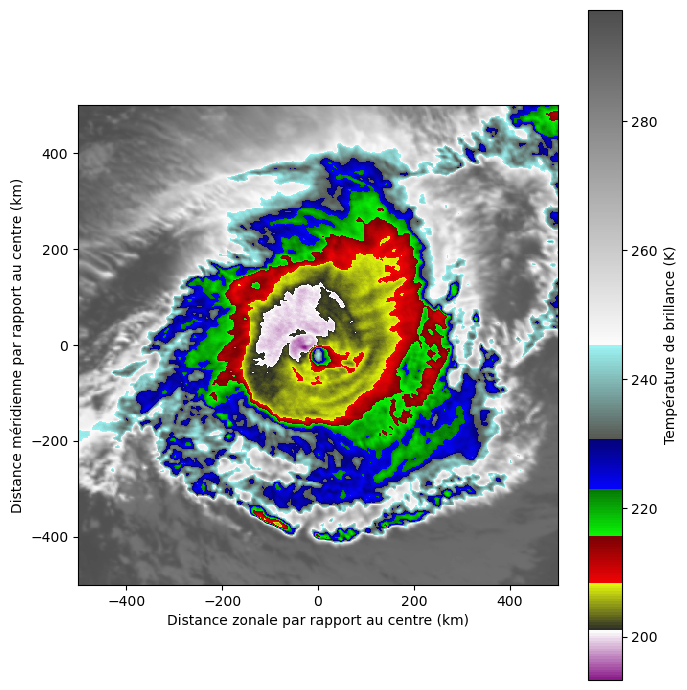

(501, 501)


In [29]:
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
anggrek_csv = pd.read_csv("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/csv_data/anggrek_coloc_sar_ir.csv")
ds = xr.open_dataset(anggrek_csv.loc[119]["ir_path"])

ir = ds["IR"][0]

fig, ax = plt.subplots(figsize=(7, 7))

im = ax.pcolormesh(
    ir["x"],
    ir["y"],
    ir,
    cmap=cmap_ir,
    shading="auto"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Température de brillance (K)")

ax.set_xlabel("Distance zonale par rapport au centre (km)")
ax.set_ylabel("Distance méridienne par rapport au centre (km)")
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("image_infrarouge.png", dpi=300, bbox_inches="tight")
plt.show()
print(ir.shape)

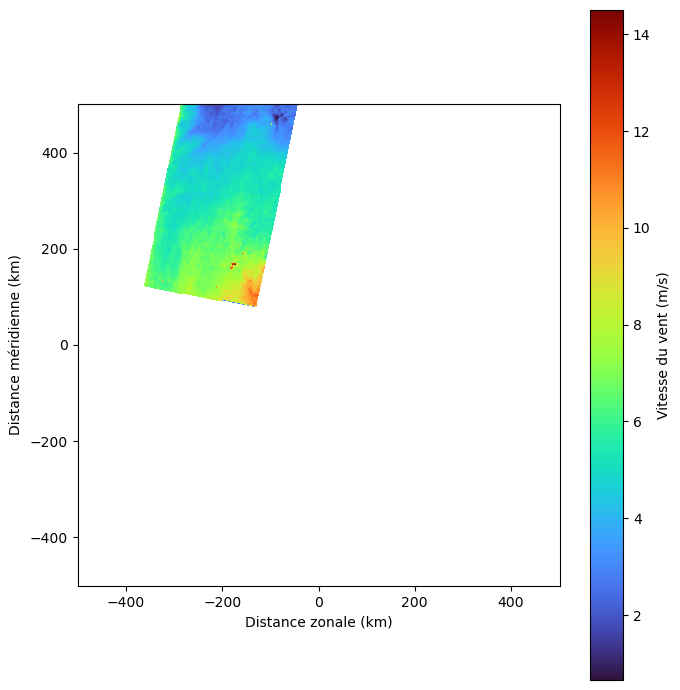

In [33]:
sar_path = "/scale/project/ifremer-isi-jumeaunumerique/IRAR_BestTrack_corrected/2022/ep192022/TC-IRAR_v02r02_EP192022_s20221022131032_e20221022131032_aeqd.nc"

ds = xr.open_dataset(sar_path)
wind = ds["wind_aeqd"]

fig, ax = plt.subplots(figsize=(7,7))

im = ax.pcolormesh(
    wind["x"],
    wind["y"],
    wind,
    cmap="turbo",
    shading="auto"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Vitesse du vent (m/s)")

ax.set_xlabel("Distance zonale (km)")
ax.set_ylabel("Distance méridienne (km)")
ax.set_aspect("equal")

plt.tight_layout()

plt.savefig("champ_vent_sar.png", dpi=300, bbox_inches="tight")

plt.show()